# Tutorial 15 — Long Short-Term Memory (LSTM)

## Objective

This notebook implements **Tutorial 15: Long Short-Term Memory (LSTM)** using PyTorch.

The tutorial covers:

- Fetching Google stock price data
- Preprocessing time-series data
- Creating sequences for prediction
- Building an LSTM model
- Training the LSTM model
- Visualizing predicted vs actual stock prices
- Predicting the next-day stock price
- Comparing LSTM with Simple RNN
- Building an LSTM model for sentiment analysis

The main tasks are:

1. Compare LSTM with Simple RNN
2. Make an LSTM model for sentiment analysis


## 1. Import Required Libraries

In [1]:
import os
import sys
import time
import random
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score

# Try importing yfinance. If it is missing, install it automatically.
try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])
        import yfinance as yf
        YFINANCE_AVAILABLE = True
    except Exception as e:
        print("yfinance could not be installed. A synthetic stock-like dataset will be used instead.")
        print("Reason:", e)
        YFINANCE_AVAILABLE = False

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

os.makedirs("images", exist_ok=True)


PyTorch version: 2.5.1+cu121
CUDA available: True
Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Fetch Google Stock Data

The tutorial uses historical Google stock data from Yahoo Finance.

The closing price is used for prediction.

If the data cannot be downloaded because of internet/package issues, the notebook automatically creates a synthetic stock-like time series so that the rest of the notebook can still run.


In [2]:
def load_google_stock_data():
    if YFINANCE_AVAILABLE:
        try:
            df = yf.download(
                "GOOGL",
                start="2010-01-01",
                end="2024-12-01",
                progress=False,
                auto_adjust=False
            )

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            if len(df) > 0 and "Close" in df.columns:
                df = df[["Close"]].dropna()
                df["Source"] = "Yahoo Finance"
                return df

        except Exception as e:
            print("Yahoo Finance download failed. Synthetic data will be used.")
            print("Reason:", e)

    # Fallback synthetic stock-like data
    np.random.seed(SEED)
    dates = pd.date_range(start="2010-01-01", periods=3500, freq="B")
    trend = np.linspace(250, 2800, len(dates))
    seasonal = 80 * np.sin(np.linspace(0, 45, len(dates)))
    noise = np.random.normal(0, 35, len(dates))
    close = trend + seasonal + noise
    close = np.maximum(close, 1)

    df = pd.DataFrame({"Close": close}, index=dates)
    df["Source"] = "Synthetic fallback"
    return df


df = load_google_stock_data()

print(df.head())
print("\nData source:", df["Source"].iloc[0])
print("Number of rows:", len(df))
print("Date range:", df.index.min(), "to", df.index.max())

data = df["Close"].values.reshape(-1, 1)


Price           Close         Source
Date                                
2010-01-04  15.684434  Yahoo Finance
2010-01-05  15.615365  Yahoo Finance
2010-01-06  15.221722  Yahoo Finance
2010-01-07  14.867367  Yahoo Finance
2010-01-08  15.065566  Yahoo Finance

Data source: Yahoo Finance
Number of rows: 3753
Date range: 2010-01-04 00:00:00 to 2024-11-29 00:00:00


## 3. Visualize Stock Closing Price

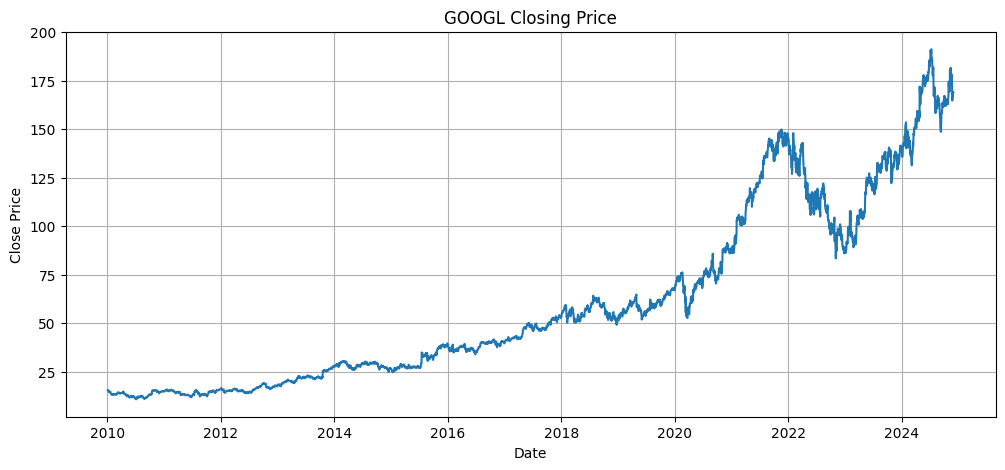

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df.index, df["Close"])
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("GOOGL Closing Price")
plt.grid(True)
plt.savefig("images/tutorial_15_google_stock_price.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Preprocess Data

The closing prices are normalized using MinMaxScaler.

A sequence length of 60 is used. This means the model uses the previous 60 days to predict the next day's closing price.


In [4]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

sequence_length = 60

def create_sequences(data_array, sequence_length):
    X = []
    y = []

    for i in range(len(data_array) - sequence_length):
        X.append(data_array[i:i + sequence_length])
        y.append(data_array[i + sequence_length])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (2942, 60, 1)
y_train shape: (2942, 1)
X_test shape: (691, 60, 1)
y_test shape: (691, 1)


## 5. Create PyTorch Dataset and DataLoader

In [5]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


batch_size = 32

train_dataset = StockDataset(X_train, y_train)
test_dataset = StockDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)


## 6. Define LSTM Model

In [6]:
class LSTMStockPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 25)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(25, output_size)

    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        # Use output from the final time step
        last_output = output[:, -1, :]

        x = self.fc1(last_output)
        x = self.relu(x)
        x = self.fc2(x)

        return x


lstm_model = LSTMStockPredictor(
    input_size=1,
    hidden_size=50,
    num_layers=2,
    output_size=1
).to(device)

print(lstm_model)


LSTMStockPredictor(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=25, out_features=1, bias=True)
)


## 7. Training and Evaluation Functions

In [7]:
def train_regression_model(model, train_loader, test_loader, epochs=20, learning_rate=0.001):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": []
    }

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_batches = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_batches += 1

        train_loss /= train_batches

        model.eval()

        test_loss = 0.0
        test_batches = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                predictions = model(batch_X)
                loss = criterion(predictions, batch_y)

                test_loss += loss.item()
                test_batches += 1

        test_loss /= test_batches

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Test Loss: {test_loss:.6f}"
            )

    total_time = time.time() - start_time

    return history, total_time


def plot_loss_curves(history, title, filename):
    epochs_range = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history["train_loss"], label="Train Loss")
    plt.plot(epochs_range, history["test_loss"], label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


def get_regression_predictions(model, data_loader):
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            batch_X = batch_X.to(device)

            batch_predictions = model(batch_X)

            predictions.extend(batch_predictions.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).reshape(-1, 1)
    actuals = np.array(actuals).reshape(-1, 1)

    return actuals, predictions


def evaluate_stock_model(model, data_loader, scaler):
    actual_scaled, predicted_scaled = get_regression_predictions(model, data_loader)

    actual = scaler.inverse_transform(actual_scaled)
    predicted = scaler.inverse_transform(predicted_scaled)

    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)

    return actual, predicted, rmse, mae


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


## 8. Train the LSTM Model

In [8]:
torch.manual_seed(SEED)

lstm_model = LSTMStockPredictor(
    input_size=1,
    hidden_size=50,
    num_layers=2,
    output_size=1
).to(device)

lstm_history, lstm_time = train_regression_model(
    lstm_model,
    train_loader,
    test_loader,
    epochs=20,
    learning_rate=0.001
)

print("LSTM training time:", round(lstm_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(lstm_model))


Epoch 1/20 | Train Loss: 0.010051 | Test Loss: 0.002415
Epoch 5/20 | Train Loss: 0.000119 | Test Loss: 0.001367
Epoch 10/20 | Train Loss: 0.000103 | Test Loss: 0.001089
Epoch 15/20 | Train Loss: 0.000095 | Test Loss: 0.000983
Epoch 20/20 | Train Loss: 0.000091 | Test Loss: 0.000775
LSTM training time: 8.88 seconds
Trainable parameters: 32301


## 9. Plot LSTM Training Curves

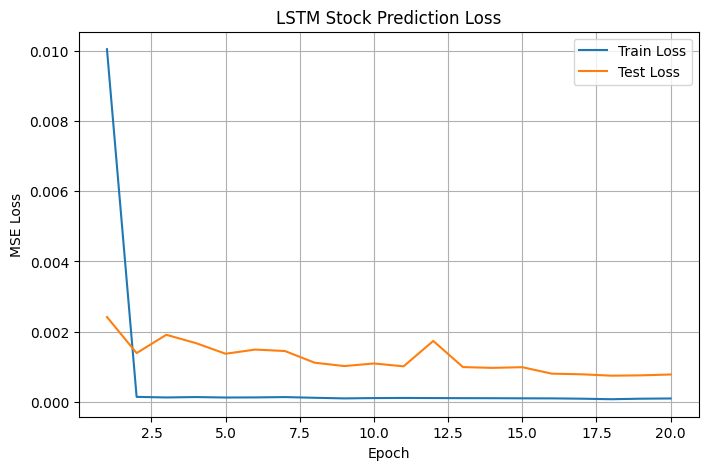

In [9]:
plot_loss_curves(
    lstm_history,
    "LSTM Stock Prediction Loss",
    "images/tutorial_15_lstm_training_curves.png"
)


## 10. Evaluate and Visualize LSTM Predictions

LSTM RMSE: 5.0122
LSTM MAE: 3.9167


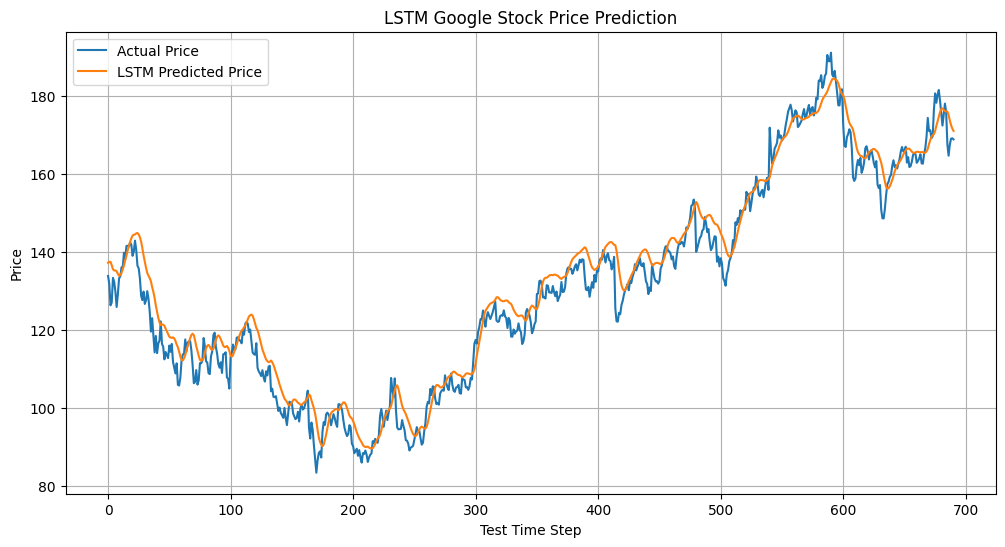

In [10]:
lstm_actual, lstm_predicted, lstm_rmse, lstm_mae = evaluate_stock_model(
    lstm_model,
    test_loader,
    scaler
)

print("LSTM RMSE:", round(lstm_rmse, 4))
print("LSTM MAE:", round(lstm_mae, 4))

plt.figure(figsize=(12, 6))
plt.plot(lstm_actual, label="Actual Price")
plt.plot(lstm_predicted, label="LSTM Predicted Price")
plt.xlabel("Test Time Step")
plt.ylabel("Price")
plt.title("LSTM Google Stock Price Prediction")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_15_lstm_predictions.png", dpi=300, bbox_inches="tight")
plt.show()


## 11. Predict the Next Day's Price

In [11]:
last_sequence = scaled_data[-sequence_length:]
last_sequence_tensor = torch.tensor(last_sequence.reshape(1, sequence_length, 1), dtype=torch.float32).to(device)

lstm_model.eval()

with torch.no_grad():
    next_day_scaled = lstm_model(last_sequence_tensor).cpu().numpy()

next_day_price = scaler.inverse_transform(next_day_scaled)

print("Predicted next day's price:", round(float(next_day_price[0][0]), 2))


Predicted next day's price: 170.68


# Task 1 — Compare LSTM with Simple RNN

A Simple RNN is trained on the same stock-price dataset and compared with the LSTM model.


In [12]:
class SimpleRNNStockPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_size, 25)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(25, output_size)

    def forward(self, x):
        output, hidden = self.rnn(x)

        last_output = output[:, -1, :]

        x = self.fc1(last_output)
        x = self.relu(x)
        x = self.fc2(x)

        return x


simple_rnn_model = SimpleRNNStockPredictor(
    input_size=1,
    hidden_size=50,
    num_layers=2,
    output_size=1
).to(device)

print(simple_rnn_model)


SimpleRNNStockPredictor(
  (rnn): RNN(1, 50, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=50, out_features=25, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=25, out_features=1, bias=True)
)


In [13]:
torch.manual_seed(SEED)

simple_rnn_model = SimpleRNNStockPredictor(
    input_size=1,
    hidden_size=50,
    num_layers=2,
    output_size=1
).to(device)

simple_rnn_history, simple_rnn_time = train_regression_model(
    simple_rnn_model,
    train_loader,
    test_loader,
    epochs=20,
    learning_rate=0.001
)

print("Simple RNN training time:", round(simple_rnn_time, 2), "seconds")
print("Trainable parameters:", count_trainable_parameters(simple_rnn_model))


Epoch 1/20 | Train Loss: 0.005029 | Test Loss: 0.002384
Epoch 5/20 | Train Loss: 0.000080 | Test Loss: 0.001310
Epoch 10/20 | Train Loss: 0.000056 | Test Loss: 0.001226
Epoch 15/20 | Train Loss: 0.000065 | Test Loss: 0.001123
Epoch 20/20 | Train Loss: 0.000058 | Test Loss: 0.001031
Simple RNN training time: 7.41 seconds
Trainable parameters: 9051


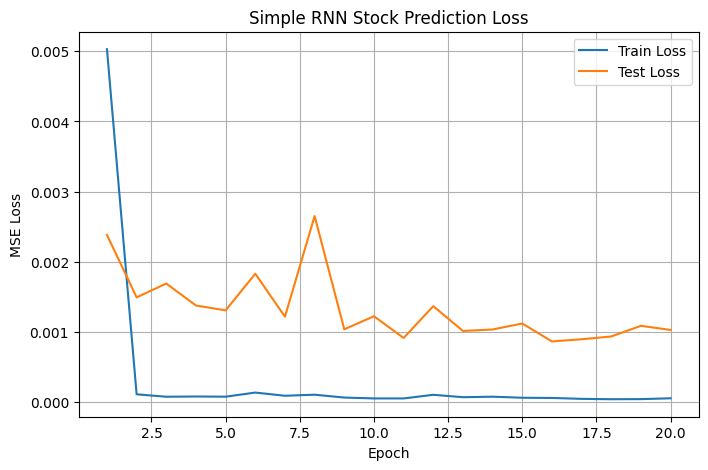

In [14]:
plot_loss_curves(
    simple_rnn_history,
    "Simple RNN Stock Prediction Loss",
    "images/tutorial_15_simple_rnn_training_curves.png"
)


Simple RNN RMSE: 5.6383
Simple RNN MAE: 4.1431


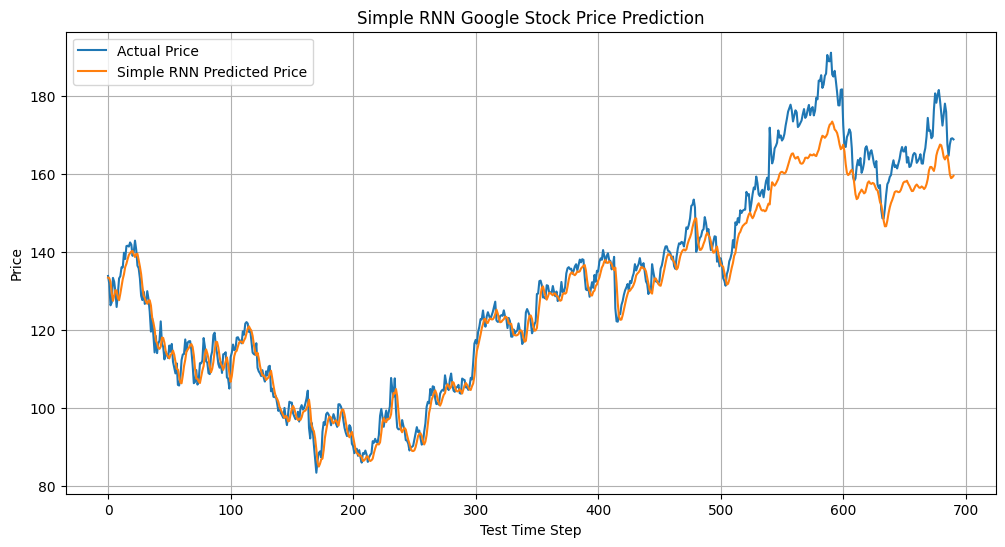

In [15]:
simple_actual, simple_predicted, simple_rmse, simple_mae = evaluate_stock_model(
    simple_rnn_model,
    test_loader,
    scaler
)

print("Simple RNN RMSE:", round(simple_rmse, 4))
print("Simple RNN MAE:", round(simple_mae, 4))

plt.figure(figsize=(12, 6))
plt.plot(simple_actual, label="Actual Price")
plt.plot(simple_predicted, label="Simple RNN Predicted Price")
plt.xlabel("Test Time Step")
plt.ylabel("Price")
plt.title("Simple RNN Google Stock Price Prediction")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_15_simple_rnn_predictions.png", dpi=300, bbox_inches="tight")
plt.show()


## 12. Compare LSTM and Simple RNN

In [16]:
comparison_df = pd.DataFrame([
    {
        "Model": "Simple RNN",
        "Trainable Parameters": count_trainable_parameters(simple_rnn_model),
        "Final Train Loss": simple_rnn_history["train_loss"][-1],
        "Final Test Loss": simple_rnn_history["test_loss"][-1],
        "RMSE": simple_rmse,
        "MAE": simple_mae,
        "Training Time (s)": simple_rnn_time
    },
    {
        "Model": "LSTM",
        "Trainable Parameters": count_trainable_parameters(lstm_model),
        "Final Train Loss": lstm_history["train_loss"][-1],
        "Final Test Loss": lstm_history["test_loss"][-1],
        "RMSE": lstm_rmse,
        "MAE": lstm_mae,
        "Training Time (s)": lstm_time
    }
])

comparison_df


,Model,Trainable Parameters,Final Train Loss,Final Test Loss,RMSE,MAE,Training Time (s)
0,Simple RNN,9051,0.000058,0.001031,5.638257,4.143103,7.407171
1,LSTM,32301,0.000091,0.000775,5.012216,3.916744,8.880079


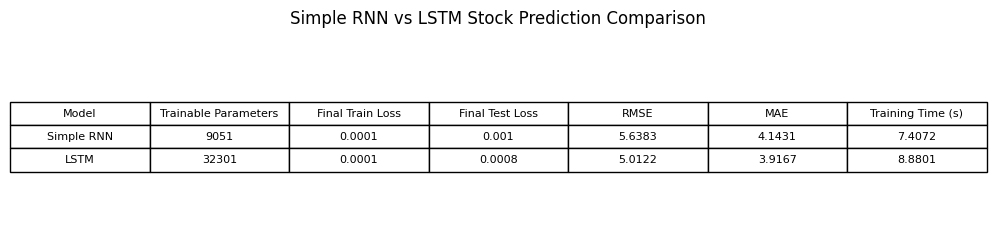

In [17]:
def save_dataframe_as_image(df, filename, title=None, fontsize=9):
    fig_width = max(8, len(df.columns) * 1.8)
    fig_height = max(2.5, len(df) * 0.5 + 1.2)

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(fontsize)
    table.scale(1, 1.4)

    if title:
        ax.set_title(title, fontsize=12, pad=12)

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


comparison_image_df = comparison_df.copy()

for column in ["Final Train Loss", "Final Test Loss", "RMSE", "MAE", "Training Time (s)"]:
    comparison_image_df[column] = comparison_image_df[column].round(4)

save_dataframe_as_image(
    comparison_image_df,
    "images/tutorial_15_model_comparison_table.png",
    title="Simple RNN vs LSTM Stock Prediction Comparison",
    fontsize=8
)


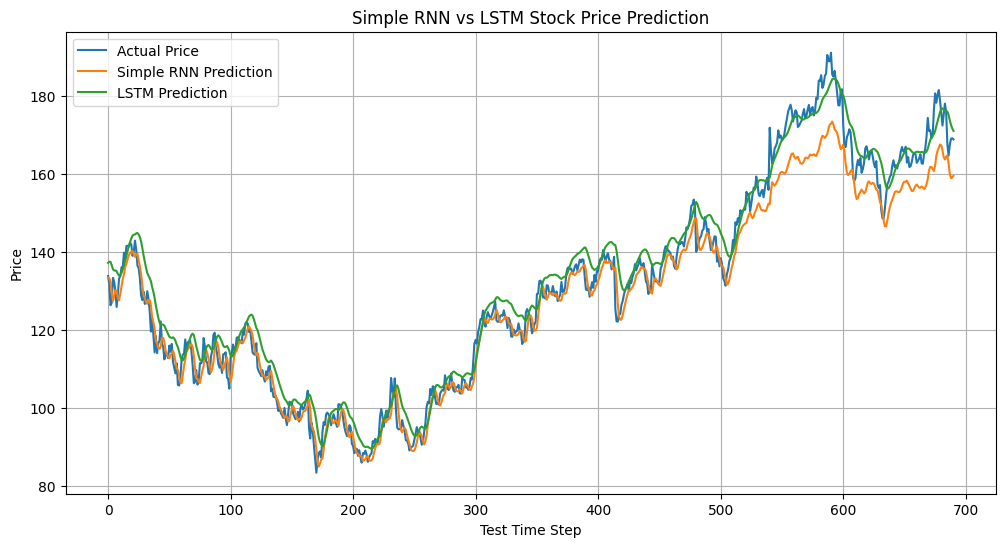

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(lstm_actual, label="Actual Price")
plt.plot(simple_predicted, label="Simple RNN Prediction")
plt.plot(lstm_predicted, label="LSTM Prediction")
plt.xlabel("Test Time Step")
plt.ylabel("Price")
plt.title("Simple RNN vs LSTM Stock Price Prediction")
plt.legend()
plt.grid(True)
plt.savefig("images/tutorial_15_simple_rnn_vs_lstm_predictions.png", dpi=300, bbox_inches="tight")
plt.show()


# Task 2 — LSTM for Sentiment Analysis

An LSTM model is also trained for sentiment analysis.

A small custom text dataset is used with two classes:

- Positive sentiment
- Negative sentiment


In [19]:
sentiment_data = [
    ("i love this product", 1),
    ("this is amazing", 1),
    ("the movie was excellent", 1),
    ("i am very happy", 1),
    ("this phone is great", 1),
    ("the service was good", 1),
    ("i enjoyed the experience", 1),
    ("the food was delicious", 1),
    ("this is very useful", 1),
    ("i like this design", 1),
    ("the result is impressive", 1),
    ("this app works perfectly", 1),
    ("i hate this product", 0),
    ("this is terrible", 0),
    ("the movie was boring", 0),
    ("i am very disappointed", 0),
    ("this phone is bad", 0),
    ("the service was poor", 0),
    ("i disliked the experience", 0),
    ("the food was awful", 0),
    ("this is useless", 0),
    ("i do not like this design", 0),
    ("the result is disappointing", 0),
    ("this app crashes often", 0),
    ("this product is not good", 0),
    ("i really enjoyed this movie", 1),
    ("the interface is clean and simple", 1),
    ("the delivery was late and bad", 0),
    ("the quality is excellent", 1),
    ("the quality is very poor", 0)
]

print("Number of sentiment samples:", len(sentiment_data))


Number of sentiment samples: 30


## 13. Prepare Sentiment Dataset

In [20]:
def tokenize_text(text):
    text = text.lower().strip()
    text = "".join(ch for ch in text if ch.isalnum() or ch.isspace())
    return text.split()

all_tokens = sorted(set(token for text, label in sentiment_data for token in tokenize_text(text)))

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

word_to_idx = {
    PAD_TOKEN: 0,
    UNK_TOKEN: 1
}

for token in all_tokens:
    word_to_idx[token] = len(word_to_idx)

idx_to_word = {idx: word for word, idx in word_to_idx.items()}

max_text_len = max(len(tokenize_text(text)) for text, label in sentiment_data)

def encode_text(text):
    tokens = tokenize_text(text)
    encoded = [word_to_idx.get(token, word_to_idx[UNK_TOKEN]) for token in tokens]

    if len(encoded) < max_text_len:
        encoded += [word_to_idx[PAD_TOKEN]] * (max_text_len - len(encoded))

    return encoded[:max_text_len]

X_sentiment = np.array([encode_text(text) for text, label in sentiment_data], dtype=np.int64)
y_sentiment = np.array([label for text, label in sentiment_data], dtype=np.int64)

print("Vocabulary size:", len(word_to_idx))
print("X shape:", X_sentiment.shape)
print("y shape:", y_sentiment.shape)


Vocabulary size: 53
X shape: (30, 6)
y shape: (30,)


In [21]:
indices = np.arange(len(sentiment_data))
np.random.seed(SEED)
np.random.shuffle(indices)

split_index = int(0.8 * len(indices))

train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_sent_train = X_sentiment[train_indices]
y_sent_train = y_sentiment[train_indices]

X_sent_test = X_sentiment[test_indices]
y_sent_test = y_sentiment[test_indices]

print("Training samples:", len(X_sent_train))
print("Testing samples:", len(X_sent_test))


Training samples: 24
Testing samples: 6


In [22]:
class SentimentDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


sent_train_dataset = SentimentDataset(X_sent_train, y_sent_train)
sent_test_dataset = SentimentDataset(X_sent_test, y_sent_test)

sent_train_loader = DataLoader(sent_train_dataset, batch_size=4, shuffle=True, num_workers=0)
sent_test_loader = DataLoader(sent_test_dataset, batch_size=4, shuffle=False, num_workers=0)


## 14. Define LSTM Sentiment Model

In [23]:
class LSTMSentimentClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_size=64, num_layers=1):
        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=word_to_idx[PAD_TOKEN]
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)

        last_hidden = hidden[-1]
        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden).squeeze(1)
        return logits


sentiment_model = LSTMSentimentClassifier(
    vocab_size=len(word_to_idx),
    embedding_dim=64,
    hidden_size=64,
    num_layers=1
).to(device)

print(sentiment_model)


LSTMSentimentClassifier(
  (embedding): Embedding(53, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


## 15. Train LSTM Sentiment Model

In [24]:
def train_sentiment_model(model, train_loader, test_loader, epochs=50, learning_rate=0.001):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "test_loss": [],
        "train_accuracy": [],
        "test_accuracy": []
    }

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_predictions = []
        train_labels = []
        train_batches = 0

        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            logits = model(batch_X)
            loss = criterion(logits, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long().cpu().numpy()

            train_predictions.extend(preds)
            train_labels.extend(batch_y.cpu().numpy())

            train_loss += loss.item()
            train_batches += 1

        train_loss /= train_batches
        train_accuracy = accuracy_score(train_labels, train_predictions)

        model.eval()

        test_loss = 0.0
        test_predictions = []
        test_labels = []
        test_batches = 0

        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device)
                batch_y = batch_y.to(device)

                logits = model(batch_X)
                loss = criterion(logits, batch_y)

                probs = torch.sigmoid(logits)
                preds = (probs >= 0.5).long().cpu().numpy()

                test_predictions.extend(preds)
                test_labels.extend(batch_y.cpu().numpy())

                test_loss += loss.item()
                test_batches += 1

        test_loss /= test_batches
        test_accuracy = accuracy_score(test_labels, test_predictions)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["train_accuracy"].append(train_accuracy)
        history["test_accuracy"].append(test_accuracy)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(
                f"Epoch {epoch + 1}/{epochs} | "
                f"Train Loss: {train_loss:.4f} | "
                f"Test Loss: {test_loss:.4f} | "
                f"Train Acc: {train_accuracy * 100:.2f}% | "
                f"Test Acc: {test_accuracy * 100:.2f}%"
            )

    return history


torch.manual_seed(SEED)

sentiment_model = LSTMSentimentClassifier(
    vocab_size=len(word_to_idx),
    embedding_dim=64,
    hidden_size=64,
    num_layers=1
).to(device)

sentiment_history = train_sentiment_model(
    sentiment_model,
    sent_train_loader,
    sent_test_loader,
    epochs=50,
    learning_rate=0.001
)


Epoch 1/50 | Train Loss: 0.6920 | Test Loss: 0.6924 | Train Acc: 45.83% | Test Acc: 50.00%
Epoch 10/50 | Train Loss: 0.4931 | Test Loss: 0.7528 | Train Acc: 91.67% | Test Acc: 16.67%
Epoch 20/50 | Train Loss: 0.0092 | Test Loss: 1.9135 | Train Acc: 100.00% | Test Acc: 33.33%
Epoch 30/50 | Train Loss: 0.0037 | Test Loss: 2.4395 | Train Acc: 100.00% | Test Acc: 16.67%
Epoch 40/50 | Train Loss: 0.0023 | Test Loss: 2.7102 | Train Acc: 100.00% | Test Acc: 16.67%
Epoch 50/50 | Train Loss: 0.0015 | Test Loss: 2.9281 | Train Acc: 100.00% | Test Acc: 16.67%


## 16. Plot Sentiment Analysis Results

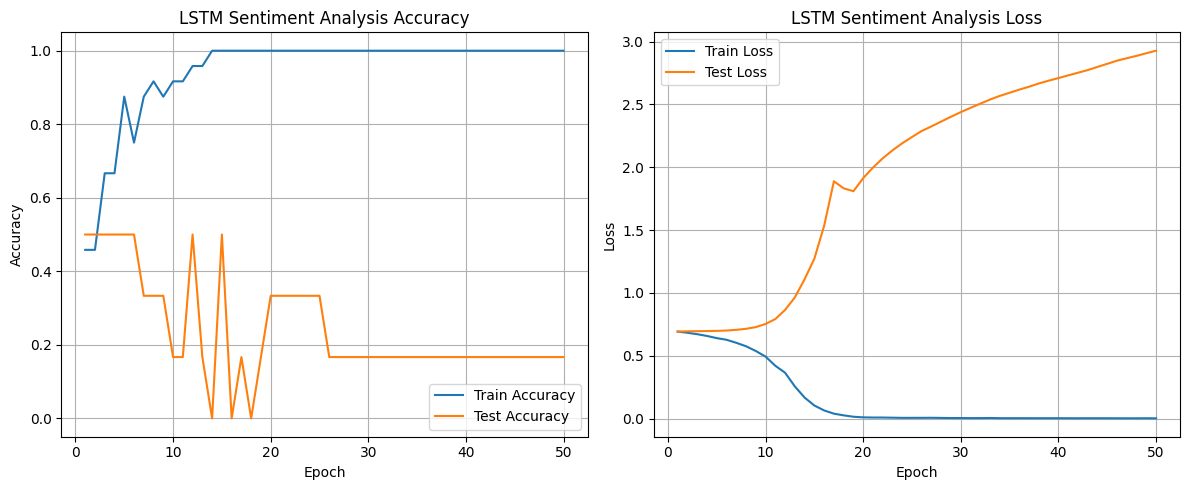

In [25]:
epochs_range = range(1, len(sentiment_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, sentiment_history["train_accuracy"], label="Train Accuracy")
plt.plot(epochs_range, sentiment_history["test_accuracy"], label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Sentiment Analysis Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, sentiment_history["train_loss"], label="Train Loss")
plt.plot(epochs_range, sentiment_history["test_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Sentiment Analysis Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("images/tutorial_15_sentiment_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()


## 17. Test Sentiment Model on New Sentences

In [26]:
def predict_sentiment(model, text):
    model.eval()

    encoded = encode_text(text)
    input_tensor = torch.tensor([encoded], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_tensor)
        probability = torch.sigmoid(logits).item()

    label = "Positive" if probability >= 0.5 else "Negative"

    return label, probability


new_sentences = [
    "this product is amazing",
    "the service was terrible",
    "i really like this app",
    "this movie is boring",
    "the quality is excellent"
]

sentiment_results = []

for sentence in new_sentences:
    label, probability = predict_sentiment(sentiment_model, sentence)
    sentiment_results.append({
        "Sentence": sentence,
        "Predicted Sentiment": label,
        "Positive Probability": probability
    })

sentiment_results_df = pd.DataFrame(sentiment_results)
sentiment_results_df


,Sentence,Predicted Sentiment,Positive Probability
0,this product is amazing,Negative,0.006673
1,the service was terrible,Negative,0.002039
2,i really like this app,Positive,0.996348
3,this movie is boring,Positive,0.998159
4,the quality is excellent,Positive,0.998425


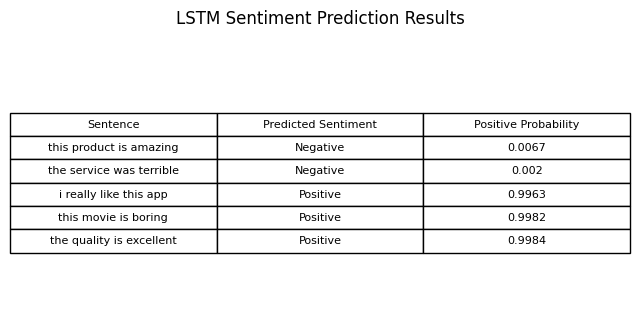

In [27]:
sentiment_results_image_df = sentiment_results_df.copy()
sentiment_results_image_df["Positive Probability"] = sentiment_results_image_df["Positive Probability"].round(4)

save_dataframe_as_image(
    sentiment_results_image_df,
    "images/tutorial_15_sentiment_prediction_table.png",
    title="LSTM Sentiment Prediction Results",
    fontsize=8
)


# Final Observations

## LSTM Stock Prediction

The LSTM model learned time-series patterns from Google stock closing prices and predicted future closing prices using the previous 60 days.

## Simple RNN Comparison

A Simple RNN was trained on the same stock dataset.  
The comparison shows how LSTM and Simple RNN perform on the same sequential prediction problem.

## Sentiment Analysis

An LSTM model was also used for binary sentiment classification.  
The model learned to classify short text sentences as positive or negative.

## Key Learning

LSTM networks are designed to handle sequential data and can learn long-term dependencies better than Simple RNNs.  
This makes them useful for tasks such as stock price prediction, language modeling, translation, and sentiment analysis.
